# Prédiction du churn client à partir du dataset Telco Customer
Ce dataset regroupe des informations relatives à des clients d’un opérateur télécom aux États-Unis.

Il comprend notamment :

- Des données démographiques

- Des informations sur les services et plans de souscription

- Des données de facturation

- Le statut de churn (résiliation)
  
## Objectif du projet
Modéliser et prédire la probabilité qu’un client résilie son contrat d’abonnement (churn).

La variable cible (target) correspond au statut de résiliation du client :

- Yes → le client a quitté l’opérateur

- No → le client est resté


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import GridSearchCV, StratifiedKFold


import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# 1. CHARGEMENT DES DONNÉES
print("=== CHARGEMENT DES DONNÉES ===")


# Download latest version
path="input/Telco_customer_churn.xlsx"
df = pd.read_excel(path)

print(df.head(5))

=== CHARGEMENT DES DONNÉES ===
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payme

In [4]:
# 2. EXPLORATION RAPIDE
print("\n=== EXPLORATION DES DONNÉES ===")

# Afficher la forme du dataset et les colonnes
print("\n")
print(f"Forme du dataset: {df.shape}")
print("\n")
print(f"Colonnes: {list(df.columns)}")

# Explorer les types de données et les valeurs manquantes
print("\n")
print("\nTypes de données et valeurs manquantes:")
print(df.info())

# Afficher les statistiques descriptives
print("\n")
print("Valeurs manquantes:")
print(df.isnull().sum())



=== EXPLORATION DES DONNÉES ===


Forme du dataset: (7043, 33)


Colonnes: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']



Types de données et valeurs manquantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   obj


=== ANALYSE EXPLORATOIRE (EDA) ===
Statistiques descriptives:
        Count      Zip Code     Latitude    Longitude  Tenure Months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       Monthly Charges  Churn Value  Churn Score         CLTV  
count      7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692     0.265370    58.699418  4400.295755  
std          30.090047     0.441561    21.525131  1183.057152  
min          18.250000     0.000

Text(0.5, 1.0, 'Distribution de la Survie')

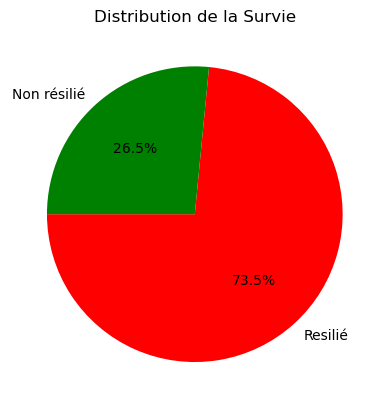

In [8]:
# 2.1 EDA - ANALYSE EXPLORATOIRE DÉTAILLÉE
print("\n=== ANALYSE EXPLORATOIRE (EDA) ===")

# Statistiques descriptives
print("Statistiques descriptives:")
print(df.describe())

print(df['Churn Label'].value_counts())


# 1. Distribution de la variable cible
plt.subplot()
churn_counts = df['Churn Label'].value_counts()
plt.pie(churn_counts.values, labels=['Resilié', 'Non résilié'], autopct='%1.1f%%', 
        colors=['red', 'green'], startangle=180)
plt.title('Distribution de la Survie')





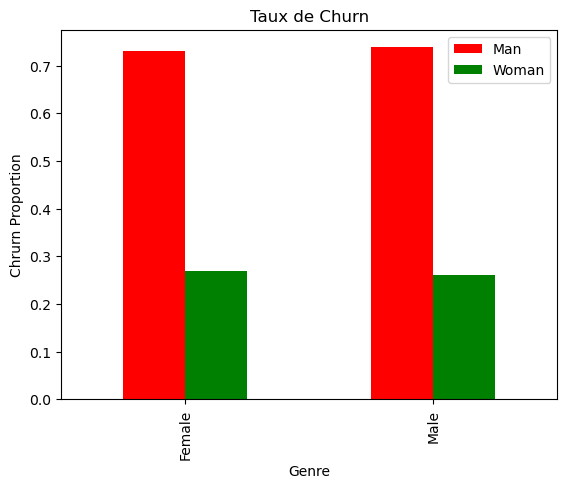

In [ ]:



# 2. Churn par gender
plt.subplot()
churn_by_gender = pd.crosstab(df['Gender'], df['Churn Label'], normalize='index')
churn_by_gender.plot(kind='bar', color=['red', 'green'], ax=plt.gca())
plt.title('Taux de Churn')
plt.xlabel('Genre')
plt.ylabel('Proportion de Churn')
plt.legend(['Man', 'Woman'])




Text(0.5, 1.0, 'Distribution de la Variable Senior Citizen')

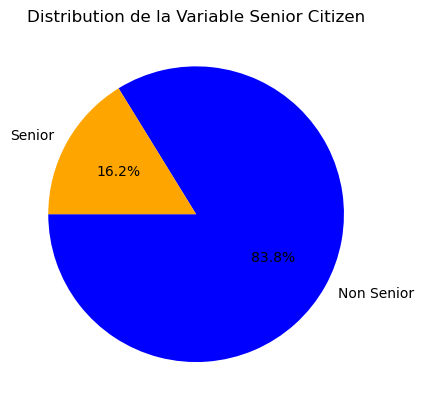

In [10]:
# 3. Distribution de la variable  senior citizen
plt.subplot()
churn_counts = df['Senior Citizen'].value_counts()
plt.pie(churn_counts.values, labels=['Non Senior', 'Senior'], autopct='%1.1f%%', 
        colors=['blue', 'orange'], startangle=180)
plt.title('Distribution de la Variable Senior Citizen')




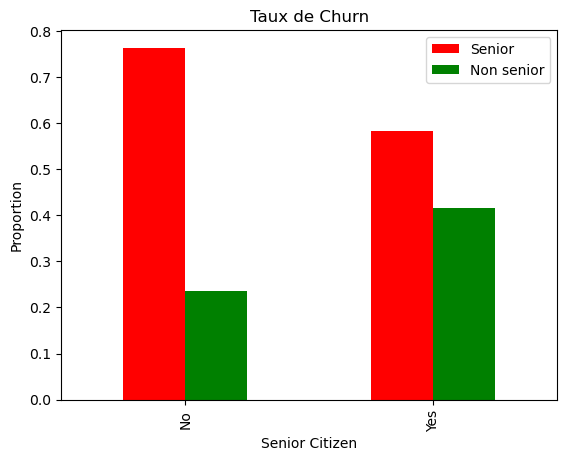

In [17]:
# 2. Churn par senior citizen
plt.subplot()
churn_by_gender = pd.crosstab(df['Senior Citizen'], df['Churn Label'], normalize='index')
churn_by_gender.plot(kind='bar', color=['red', 'green'], ax=plt.gca())
plt.title('Taux de Churn')
plt.xlabel('Senior Citizen')
plt.ylabel('Proportion')
plt.legend(['Senior', 'Non senior'])

    Latitude   Longitude  Tenure Months  Monthly Charges  CLTV
0  33.964131 -118.272783              2            53.85  3239
1  34.059281 -118.307420              2            70.70  2701
2  34.048013 -118.293953              8            99.65  5372
3  34.062125 -118.315709             28           104.80  5003
4  34.039224 -118.266293             49           103.70  5340


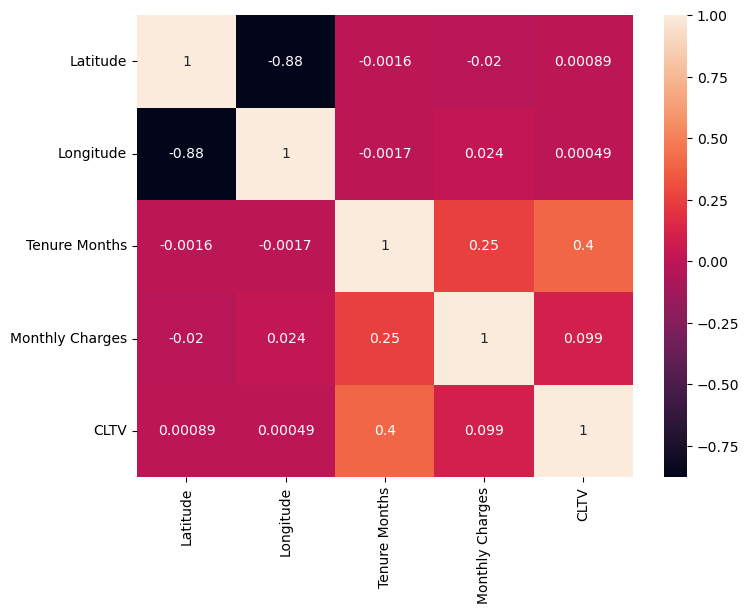

In [ ]:
df_numeric = df.select_dtypes(include=np.number).drop(columns=['Zip Code','Churn Value','Churn Score','Count'])
print(df_numeric.head())
corr_df = df_numeric.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True)
plt.show()

## il ya une correlation entre tenure et CLTV et une correlation inversé entre longitude et latitude. si modele lineaire 
# on peut garder soit la longitude soit la latitude et supprimer l'autre. 

Text(0, 0.5, 'Tenure (mois)')

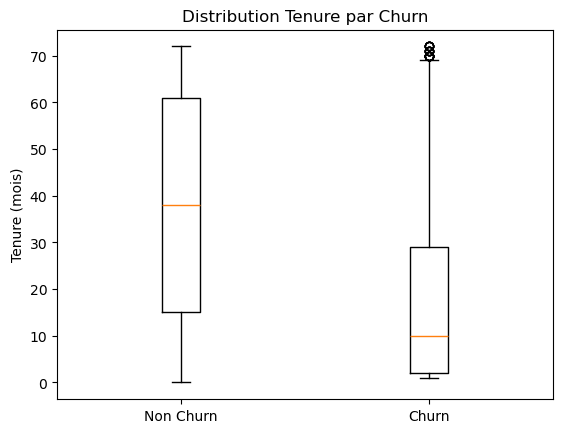

In [ ]:
# 5. Churn par Tenure (boxplot)
plt.subplot()
churn_tenure = df[df['Churn Label'] == 'Yes']['Tenure Months'].dropna()
not_churn_tenure = df[df['Churn Label'] == 'No']['Tenure Months'].dropna()
plt.boxplot([not_churn_tenure, churn_tenure], tick_labels=['Non Churn', 'Churn'])
plt.title('Distribution Tenure par Churn')
plt.ylabel('Tenure (mois)')

## Les personnes qui ont churné ont tendance à avoir une tenure plus courte que celles qui n'ont pas churné, 
# ce qui suggère que les clients qui restent plus longtemps sont moins susceptibles de résilier
# On a quelques outliers plutot dans le groupe des churnés, ce qui peut indiquer que certains clients résilient même après une longue période de fidélité.